# Notebook 7 — Fuel Price Sensitivity

Given a fixed energy mix, how **exposed** is the electricity price to fuel price shocks? This notebook answers that question.

Topics:
1. 1D gas price sweep — electricity price as a function of gas cost
2. 1D coal price sweep — same for coal
3. 2D heatmap — gas × coal price interaction
4. Sensitivity coefficients — $\partial P_{\text{elec}} / \partial P_{\text{fuel}}$

**Runtime**: ~90 seconds

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from energy_sim.config import ITALIAN_MIX, GAS_SCENARIOS, COAL_SCENARIOS
from energy_sim.simulation import sweep_fuel_price, sweep_fuel_prices_2d

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Gas Price Sweep

How does the electricity price respond to changes in gas cost? We sweep gas $\mu$ from 20 to 100 EUR/MWh_th, keeping everything else fixed.

In [2]:
gas_sweep = sweep_fuel_price(
    ITALIAN_MIX, 'gas',
    mu_range=np.linspace(20, 100, 9),
    base_gas_scenario=GAS_SCENARIOS['base'],
    n_runs=10, seed=42,
)

  gas μ=20: elec_price=57.67 EUR/MWh, CI=217 gCO₂/kWh
  gas μ=30: elec_price=74.83 EUR/MWh, CI=217 gCO₂/kWh
  gas μ=40: elec_price=92.00 EUR/MWh, CI=217 gCO₂/kWh
  gas μ=50: elec_price=109.16 EUR/MWh, CI=217 gCO₂/kWh
  gas μ=60: elec_price=126.32 EUR/MWh, CI=217 gCO₂/kWh
  gas μ=70: elec_price=143.49 EUR/MWh, CI=217 gCO₂/kWh
  gas μ=80: elec_price=160.65 EUR/MWh, CI=217 gCO₂/kWh
  gas μ=90: elec_price=177.81 EUR/MWh, CI=217 gCO₂/kWh
  gas μ=100: elec_price=194.98 EUR/MWh, CI=217 gCO₂/kWh


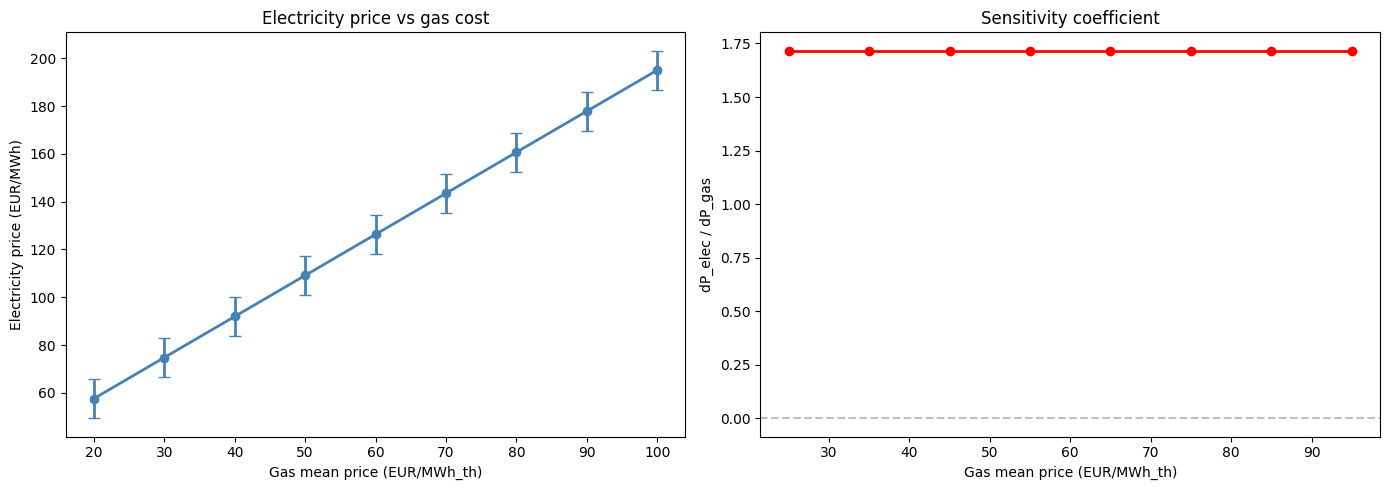

Average sensitivity: 1.716 EUR_elec per EUR_gas
  (1 EUR increase in gas cost raises electricity by ~1.72 EUR)


In [3]:
gas_mus = [r['fuel_mu'] for r in gas_sweep]
elec_prices = [r['mean_price'] for r in gas_sweep]
elec_stds = [r['std_price'] for r in gas_sweep]
cis = [r['mean_carbon_intensity'] for r in gas_sweep]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(gas_mus, elec_prices, yerr=elec_stds, fmt='o-',
                 color='steelblue', capsize=4, lw=2)
axes[0].set_xlabel('Gas mean price (EUR/MWh_th)')
axes[0].set_ylabel('Electricity price (EUR/MWh)')
axes[0].set_title('Electricity price vs gas cost')

# Sensitivity coefficient (finite difference)
dP = np.diff(elec_prices)
dF = np.diff(gas_mus)
sensitivity = dP / dF
mid_mus = [(gas_mus[i] + gas_mus[i+1])/2 for i in range(len(dP))]

axes[1].plot(mid_mus, sensitivity, 'o-', color='red', lw=2)
axes[1].set_xlabel('Gas mean price (EUR/MWh_th)')
axes[1].set_ylabel('dP_elec / dP_gas')
axes[1].set_title('Sensitivity coefficient')
axes[1].axhline(0, color='gray', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Average sensitivity: {np.mean(sensitivity):.3f} EUR_elec per EUR_gas")
print(f"  (1 EUR increase in gas cost raises electricity by ~{np.mean(sensitivity):.2f} EUR)")

## 2. Coal Price Sweep

  coal μ=5: elec_price=83.42 EUR/MWh, CI=217 gCO₂/kWh
  coal μ=10: elec_price=83.42 EUR/MWh, CI=217 gCO₂/kWh
  coal μ=15: elec_price=83.42 EUR/MWh, CI=217 gCO₂/kWh
  coal μ=20: elec_price=83.42 EUR/MWh, CI=217 gCO₂/kWh
  coal μ=25: elec_price=83.42 EUR/MWh, CI=217 gCO₂/kWh
  coal μ=30: elec_price=83.42 EUR/MWh, CI=217 gCO₂/kWh
  coal μ=35: elec_price=83.42 EUR/MWh, CI=217 gCO₂/kWh


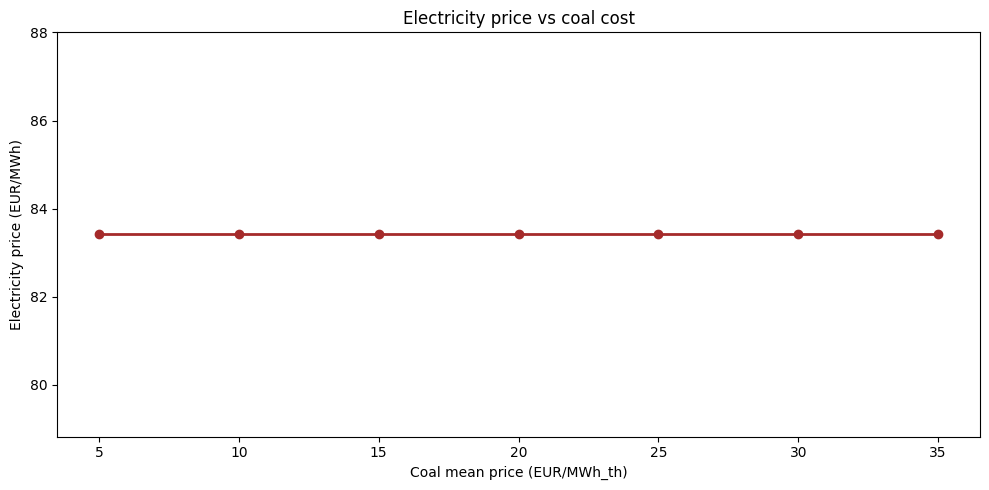

Note: with 0 GW coal in the default Italian mix, coal price has minimal effect.
Coal sensitivity only appears when coal capacity > 0.


In [4]:
coal_sweep = sweep_fuel_price(
    ITALIAN_MIX, 'coal',
    mu_range=np.linspace(5, 35, 7),
    base_gas_scenario=GAS_SCENARIOS['base'],
    n_runs=10, seed=42,
)

coal_mus = [r['fuel_mu'] for r in coal_sweep]
coal_elec_prices = [r['mean_price'] for r in coal_sweep]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(coal_mus, coal_elec_prices, 'o-', color='brown', lw=2)
ax.set_xlabel('Coal mean price (EUR/MWh_th)')
ax.set_ylabel('Electricity price (EUR/MWh)')
ax.set_title('Electricity price vs coal cost')
plt.tight_layout()
plt.show()

print(f"Note: with 0 GW coal in the default Italian mix, coal price has minimal effect.")
print(f"Coal sensitivity only appears when coal capacity > 0.")

## 3. 2D Heatmap: Gas × Coal

With a mix that includes both gas and coal, the interaction between their prices reveals **fuel-switching** dynamics:

In [5]:
from copy import deepcopy

# Add coal to the mix to see the 2D interaction
mix_with_coal = deepcopy(ITALIAN_MIX)
mix_with_coal['coal']['capacity_gw'] = 10.0  # 10 GW coal

price_2d, ci_2d = sweep_fuel_prices_2d(
    mix_with_coal,
    gas_mu_range=np.array([25, 50, 75, 100]),
    coal_mu_range=np.array([8, 15, 25]),
    base_gas_scenario=GAS_SCENARIOS['base'],
    n_runs=10, seed=42,
)

  gas_μ=25, coal_μ=8: price=66.44 EUR/MWh, CI=237 gCO₂/kWh
  gas_μ=25, coal_μ=15: price=66.76 EUR/MWh, CI=218 gCO₂/kWh
  gas_μ=25, coal_μ=25: price=67.19 EUR/MWh, CI=218 gCO₂/kWh
  gas_μ=50, coal_μ=8: price=107.23 EUR/MWh, CI=344 gCO₂/kWh
  gas_μ=50, coal_μ=15: price=108.27 EUR/MWh, CI=322 gCO₂/kWh
  gas_μ=50, coal_μ=25: price=109.33 EUR/MWh, CI=238 gCO₂/kWh
  gas_μ=75, coal_μ=8: price=147.49 EUR/MWh, CI=344 gCO₂/kWh
  gas_μ=75, coal_μ=15: price=148.56 EUR/MWh, CI=344 gCO₂/kWh
  gas_μ=75, coal_μ=25: price=150.10 EUR/MWh, CI=344 gCO₂/kWh
  gas_μ=100, coal_μ=8: price=187.76 EUR/MWh, CI=344 gCO₂/kWh
  gas_μ=100, coal_μ=15: price=188.83 EUR/MWh, CI=344 gCO₂/kWh
  gas_μ=100, coal_μ=25: price=190.36 EUR/MWh, CI=344 gCO₂/kWh


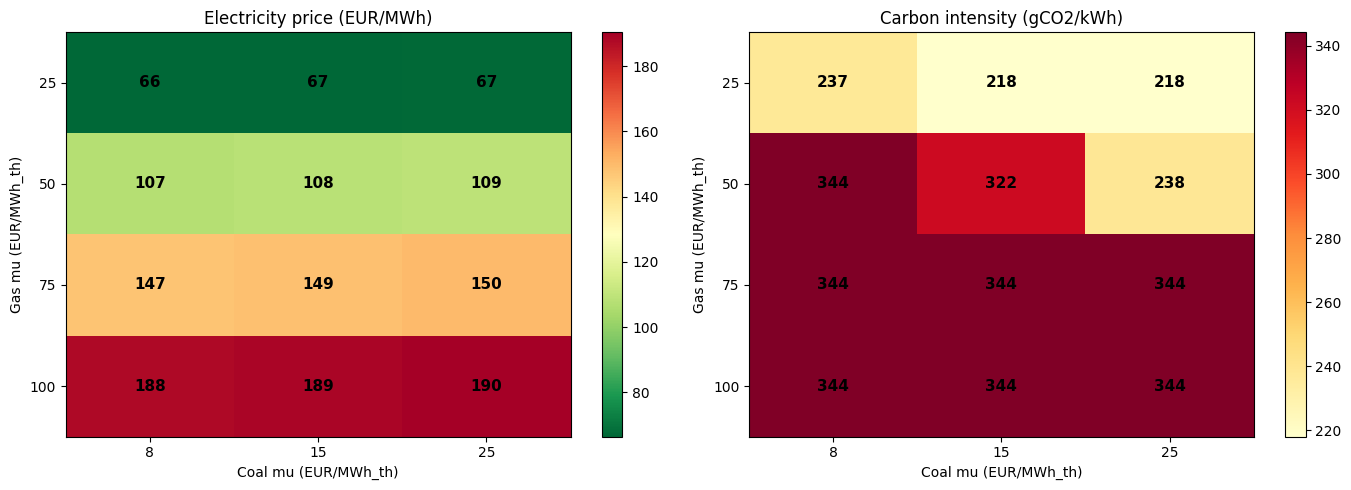

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gas_labels = [25, 50, 75, 100]
coal_labels = [8, 15, 25]

for ax, data, title, cmap in [
    (axes[0], price_2d, 'Electricity price (EUR/MWh)', 'RdYlGn_r'),
    (axes[1], ci_2d, 'Carbon intensity (gCO2/kWh)', 'YlOrRd'),
]:
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(coal_labels)))
    ax.set_xticklabels([f'{c}' for c in coal_labels])
    ax.set_yticks(range(len(gas_labels)))
    ax.set_yticklabels([f'{g}' for g in gas_labels])
    ax.set_xlabel('Coal mu (EUR/MWh_th)')
    ax.set_ylabel('Gas mu (EUR/MWh_th)')
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f'{data[i,j]:.0f}', ha='center', va='center',
                    fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Key Takeaways

1. The **sensitivity coefficient** $\partial P_{\text{elec}} / \partial P_{\text{gas}}$ measures direct fuel exposure. For the Italian mix (gas-dominated), it's typically 1.5-2.0 — every EUR increase in gas cost raises electricity by ~1.7 EUR.
2. **Coal price** has minimal effect when coal isn't in the mix. When present, it shows lower sensitivity than gas (coal is a baseload fuel, less often marginal).
3. The **2D heatmap** reveals fuel-switching: when gas is cheap and coal is expensive, the system runs on gas (low emissions). When gas is expensive and coal is cheap, coal dispatches more (high emissions).
4. These sensitivities quantify **energy security risk** — mixes with diversified fuel exposure are more resilient to price shocks.

**Next notebook**: [08 — Emissions Tracking](./08_emissions_tracking.ipynb) — CO2 accounting and carbon policy.